# MNIST DataModule

This notebook defines the MNISTDataModule using fsspec for URI-based data loading.

In [8]:
#| default_exp datamodules.mnist_datamodule

All the code in this notebook is exported to `src/datamodules/mnist_datamodule.py`

Cells marked `#| export` are exported. Any cells without this are meant for running and testing in-notebook

In [9]:
#| export
from typing import Optional, Tuple
import os

import fsspec
import torch
from pytorch_lightning import LightningDataModule
from torch.utils.data import ConcatDataset, DataLoader, Dataset, random_split
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

## Data Preparation

The `prepare_data` method downloads the MNIST dataset if it's not already available. It uses `fsspec` to handle different URI schemes, caching remote data locally if necessary.

This method is called only once per GPU in distributed mode, making it ideal for downloading or syncing large datasets.

In [10]:
#| export
from fastcore.utils import patch
from src.lightning_config import lightning_config

@lightning_config
class MNISTDataModule(LightningDataModule):
    """Example of LightningDataModule for MNIST dataset using fsspec for URI-based loading.

    A DataModule implements 5 key methods:
        - prepare_data (things to do on 1 GPU/TPU in distributed mode)
        - setup (things to do on every accelerator in distributed mode)
        - train_dataloader (the training dataloader)
        - val_dataloader (the validation dataloader(s))
        - test_dataloader (the test dataloader(s))

    This allows you to share a full dataset without explaining how to download,
    split, transform and process the data.

    Read the docs:
        https://pytorch-lightning.readthedocs.io/en/latest/extensions/datamodules.html
    """

    def __init__(
        self,
        data_uri: str = "file://./data/",
        train_val_test_split: Tuple[int, int, int] = (55_000, 5_000, 10_000),
        batch_size: int = 64,
        num_workers: int = 0,
        pin_memory: bool = False,
    ):
        super().__init__()

        # this line allows to access init params with 'self.hparams' attribute
        self.save_hyperparameters(logger=False)

        # data transformations
        self.transforms = transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
        )

        self.data_train: Optional[Dataset] = None
        self.data_val: Optional[Dataset] = None
        self.data_test: Optional[Dataset] = None

    @property
    def num_classes(self) -> int:
        return 10

We use the `@patch` decorator to add methods one by one, instead of using a single giant cell that defeats the purpose of a clean, organized, well-documented notebook

In [11]:
#| export
@patch
def prepare_data(self: MNISTDataModule):
    """Download data if needed, using fsspec for URI handling.

    This method is called only from a single GPU.
    Do not use it to assign state (self.x = y).
    """
    fs, path = fsspec.core.url_to_fs(self.hparams.data_uri)
    if fs.protocol != 'file':
        # For remote URIs, cache to local
        local_path = "./data"
        os.makedirs(local_path, exist_ok=True)
        fs.get(path.rstrip('/'), local_path, recursive=True)
        data_dir = local_path
    else:
        data_dir = path
    
    MNIST(data_dir, train=True, download=True)
    MNIST(data_dir, train=False, download=True)

## Data Setup

The `setup` method loads the datasets and splits them into train, validation, and test sets. It uses the URI-based data location from `prepare_data` and applies the appropriate transforms.

In [12]:
#| export
@patch
def setup(self: MNISTDataModule, stage: Optional[str] = None):
    """Load data. Set variables: `self.data_train`, `self.data_val`, `self.data_test`.

    This method is called by lightning when doing `trainer.fit()` and `trainer.test()`,
    so be careful not to execute the random split twice! The `stage` can be used to
    differentiate whether it's called before trainer.fit()` or `trainer.test()`.
    """

    # load datasets only if they're not loaded already
    if not self.data_train and not self.data_val and not self.data_test:
        fs, path = fsspec.core.url_to_fs(self.hparams.data_uri)
        if fs.protocol != 'file':
            data_dir = "./data"
        else:
            data_dir = path
        
        trainset = MNIST(
            data_dir, train=True, transform=self.transforms
        )
        testset = MNIST(
            data_dir, train=False, transform=self.transforms
        )
        dataset = ConcatDataset(datasets=[trainset, testset])
        self.data_train, self.data_val, self.data_test = random_split(
            dataset=dataset,
            lengths=self.hparams.train_val_test_split,
            generator=torch.Generator().manual_seed(42),
        )

## DataLoaders

The dataloader methods create PyTorch DataLoaders for each phase of training. The training loader shuffles the data, while validation and test loaders do not.

In [13]:
#| export
@patch
def train_dataloader(self: MNISTDataModule):
    return DataLoader(
        dataset=self.data_train,
        batch_size=self.hparams.batch_size,
        num_workers=self.hparams.num_workers,
        pin_memory=self.hparams.pin_memory,
        shuffle=True,
    )

@patch
def val_dataloader(self: MNISTDataModule):
    return DataLoader(
        dataset=self.data_val,
        batch_size=self.hparams.batch_size,
        num_workers=self.hparams.num_workers,
        pin_memory=self.hparams.pin_memory,
        shuffle=False,
    )

@patch
def test_dataloader(self: MNISTDataModule):
    return DataLoader(
        dataset=self.data_test,
        batch_size=self.hparams.batch_size,
        num_workers=self.hparams.num_workers,
        pin_memory=self.hparams.pin_memory,
        shuffle=False,
    )

## Testing & Validation

This section demonstrates how to use the MNISTDataModule and validates that data is loaded and preprocessed correctly. Run these cells interactively to verify the datamodule works as expected.

### Setup: Instantiate and Initialize

First, we create an instance of the datamodule and call `setup()` to load and split the MNIST dataset. This simulates what happens during training when Lightning calls these methods automatically.

In [ ]:
# NOT exported - for testing only

# Instantiate with default parameters
dm = MNISTDataModule(batch_size=32, num_workers=0)

# Download data (called only once per GPU in distributed mode)
dm.prepare_data()

# Load and split data
dm.setup()

print("DataModule initialized and data loaded successfully")
print(f"  Training samples: {len(dm.data_train)}")
print(f"  Validation samples: {len(dm.data_val)}")
print(f"  Test samples: {len(dm.data_test)}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.78MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 294kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 939kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 959kB/s]

✓ DataModule initialized and data loaded successfully
  Training samples: 55000
  Validation samples: 5000
  Test samples: 10000


### Inspect Batch Properties

Load a batch from the training dataloader and verify:
- **Shapes**: Images should be (batch_size, 1, 28, 28) and labels (batch_size,)
- **Data types**: Images as float32, labels as int64
- **Value ranges**: Images normalized to ~[-1, 3] (standardized), labels in [0, 9]
- **Visual quality**: MNIST digits should be clearly recognizable

BATCH STATISTICS
Images shape: torch.Size([32, 1, 28, 28])
Labels shape: torch.Size([32])
Image dtype: torch.float32, Label dtype: torch.int64

Image value ranges:
  Min: -0.4242, Max: 2.8215
  Mean: -0.0022, Std: 0.9967

Label distribution: [4 4 1 3 2 3 4 3 3 5]

SAMPLE IMAGES FROM BATCH


/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savef

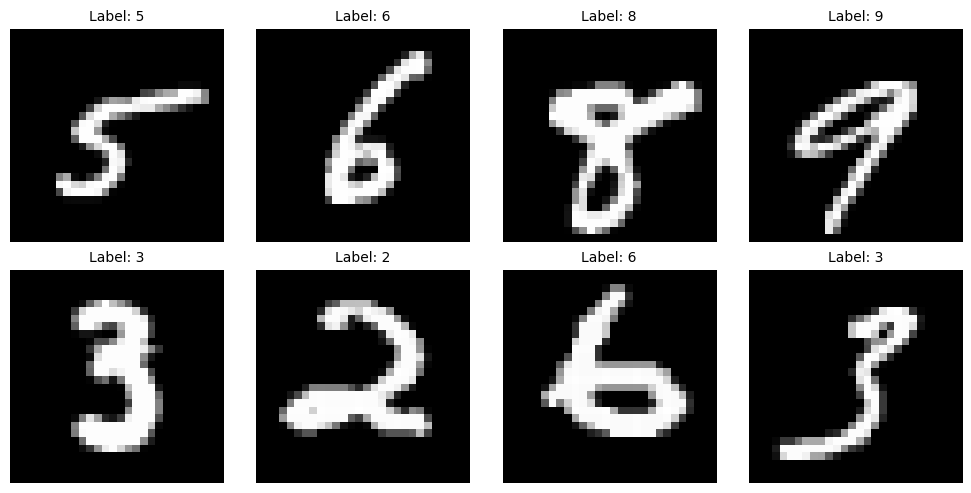


✓ Batch visualization complete


In [ ]:
# NOT exported - for testing only
import matplotlib.pyplot as plt
import numpy as np

# Get a batch from training dataloader
train_loader = dm.train_dataloader()
images, labels = next(iter(train_loader))

# Print batch statistics
print("=" * 60)
print("BATCH STATISTICS")
print("=" * 60)
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
print(f"\nImage value ranges:")
print(f"  Min: {images.min():.4f}, Max: {images.max():.4f}")
print(f"  Mean: {images.mean():.4f}, Std: {images.std():.4f}")
print(f"\nLabel distribution: {np.bincount(labels.numpy())}")

# Visualize first 8 images
print("\n" + "=" * 60)
print("SAMPLE IMAGES FROM BATCH")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i, 0].numpy()  # Remove channel dimension
    label = labels[i].item()
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Batch visualization complete")

### Validation Checks

The output above should show:

1. **Shapes**: `images: (32, 1, 28, 28)`, `labels: (32,)` — batch size 32, single channel, 28×28 pixels
2. **Normalization**: Image values in ~[-0.5, 2.8] range (standardized using mean=0.1307, std=0.3081)
3. **Labels**: Integers 0-9, roughly evenly distributed across the batch
4. **Visual quality**: Displayed digits should be clear and recognizable MNIST handwritten numbers

If any of these look wrong, check:
- Dataset download completed successfully in `./data/`
- Transforms are applied correctly (check `transforms.Compose`)
- Data splits are correct (55k train, 5k val, 10k test)